# Introdução ao Scikit-Learn e avaliação do modelo

objetivos do aprendizado:

- Explicar a variável de resposta
- Descrever as implicações de dados desbalanceados na classificação binária
- Dividir os dados em conjuntos de treinamento e teste
- Descrever o ajuste do modelo no scikit-learn 
- Derivar varias métricas para a classificação binária
- Criar uma curva ROC e uma curva precision-recall

In [46]:
!pip install scikit-learn
from sklearn.linear_model import LogisticRegression
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib as mpl 
mpl.rcParams['figure.dpi'] = 400

df = pd.read_csv('Data/Chapter_1_cleaned_data.csv')
df['default payment next month'].mean()

np.float64(0.2217971797179718)

In [47]:
df.groupby('default payment next month')['ID'].count()

default payment next month
0    20750
1     5914
Name: ID, dtype: int64

In [48]:
# selecionar o modelo e instancia-lo a partir da classe fornecida pelo scikit-learn
my_new_lr = LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True, intercept_scaling=1, max_iter=100,
                           n_jobs=None, penalty='l2', random_state=None, solver='liblinear', tol=0.0001,
                           verbose=0, warm_start=False)
my_new_lr

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [49]:
my_new_lr.C = 0.1
my_new_lr.solver = 'liblinear'
my_new_lr

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [50]:
#tomando emprestadas do dataset as 10 primeiras amostras de uma unica característica
X = df['EDUCATION'][0:10].values.reshape(-1, 1)
X

array([[2],
       [2],
       [2],
       [2],
       [2],
       [1],
       [1],
       [2],
       [3],
       [3]])

In [51]:
y = df['default payment next month'][0:10].values
y

array([1, 1, 0, 0, 0, 0, 0, 0, 0, 0])

In [52]:
my_new_lr.fit(X, y)

/home/aimee/Área de trabalho/Data-Science-Project-Python-LEARNING/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [53]:
#já conseguimos utyilizar o modelo treinado para fazer previsões, iremos prever as 10 proximas linhas da característica EDUCATION
new_X = df['EDUCATION'][10:20].values.reshape(-1, 1)
new_X

array([[3],
       [1],
       [2],
       [2],
       [1],
       [3],
       [1],
       [1],
       [1],
       [3]])

In [54]:
# as previsões são feitas utilizando o método predict, iremos prever o y agora
my_new_lr.predict(new_X)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [55]:
#rotulos reais correspondentes
df['default payment next month'][10:20].values

array([0, 0, 0, 1, 0, 0, 1, 0, 0, 0])

Gerando dados sintéticos

In [56]:
#Gerando dados aleatórios
np.random.seed(seed=1)
X = np.random.uniform(low=0.0, high=10.0, size=(1000,))
X[0:10]

array([4.17022005e+00, 7.20324493e+00, 1.14374817e-03, 3.02332573e+00,
       1.46755891e+00, 9.23385948e-01, 1.86260211e+00, 3.45560727e+00,
       3.96767474e+00, 5.38816734e+00])

Dados para uma regressão linear simples

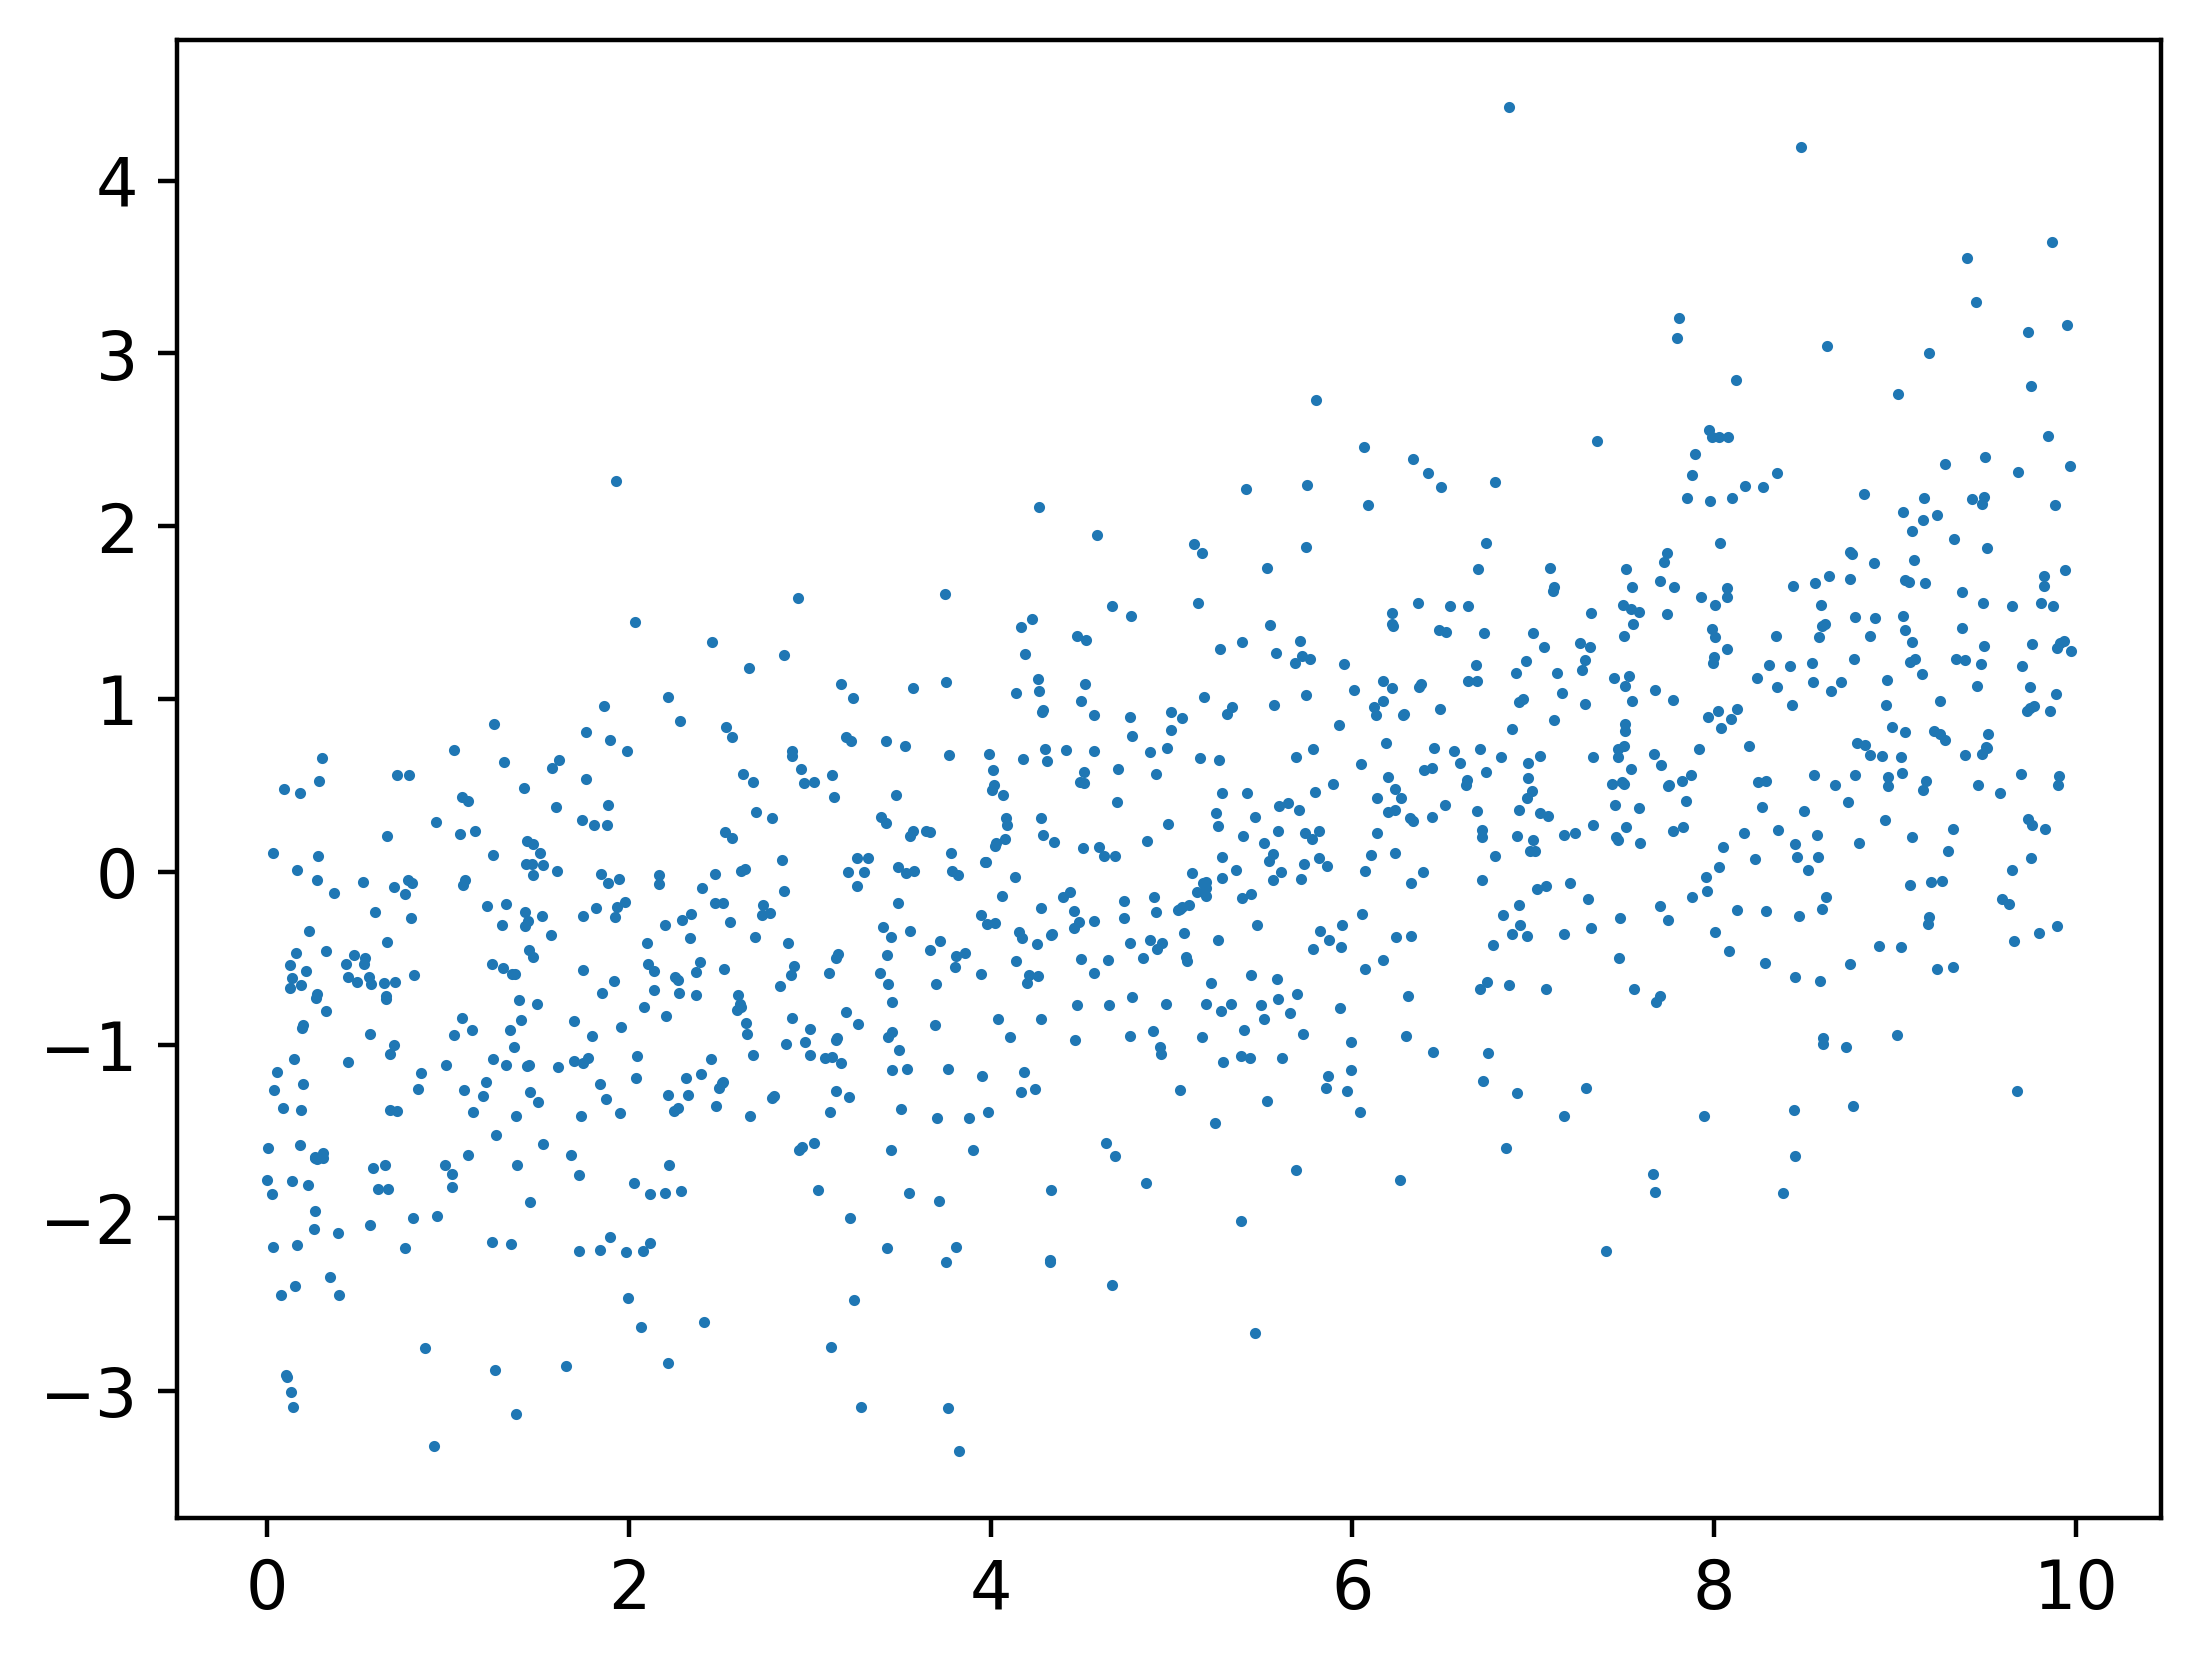

In [57]:
#1. definir o seed aleatorio
np.random.seed(seed=1)

#2. declarar variaveis para a inclinacao e a interceptacao de nossos dados lineares
slope = 0.25
intercept = -1.25

#3.criar a variavel de resposta usando a equacao familiar de uma linha, com o acrescimo de um ruido gaussiano
y = slope * X + np.random.normal(loc=0.0, scale=1.0, size=(1000,)) + intercept

#4. plotar os dados
mpl.rcParams['figure.dpi'] = 400
plt.scatter(X, y, s=1)

Regressao linear com o scikit-learn

In [58]:
#1. importar a classe LinearRegression do modulo linear_model do scikit-learn
from sklearn.linear_model import LinearRegression
#2. instanciar a classe LinearRegression
lin_reg = LinearRegression()
lin_reg

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [59]:
#1. ajustar o modelo usando nossos dados sinteticos, lembrando de redimensionar o array de características. Para que as amostras fiquem ao longo
#da primeira dimensão
lin_reg.fit(X.reshape(-1, 1), y)
#2. examinar lin_reg.intercept_ e lin_reg.coef_ que contem, respectivamente, a interceptação e o coeficiente (inclinação) da linha ajustada
print(lin_reg.intercept_)
print(lin_reg.coef_)

-1.1612566002825888
[0.24002588]


In [60]:
#fazer as previsões
y_pred = lin_reg.predict(X.reshape(-1, 1))
y_pred[0:10]

array([-0.16029588,  0.56770858, -1.16098207, -0.43558019, -0.80900449,
       -0.93962008, -0.7141839 , -0.33182144, -0.20891199,  0.13204299])

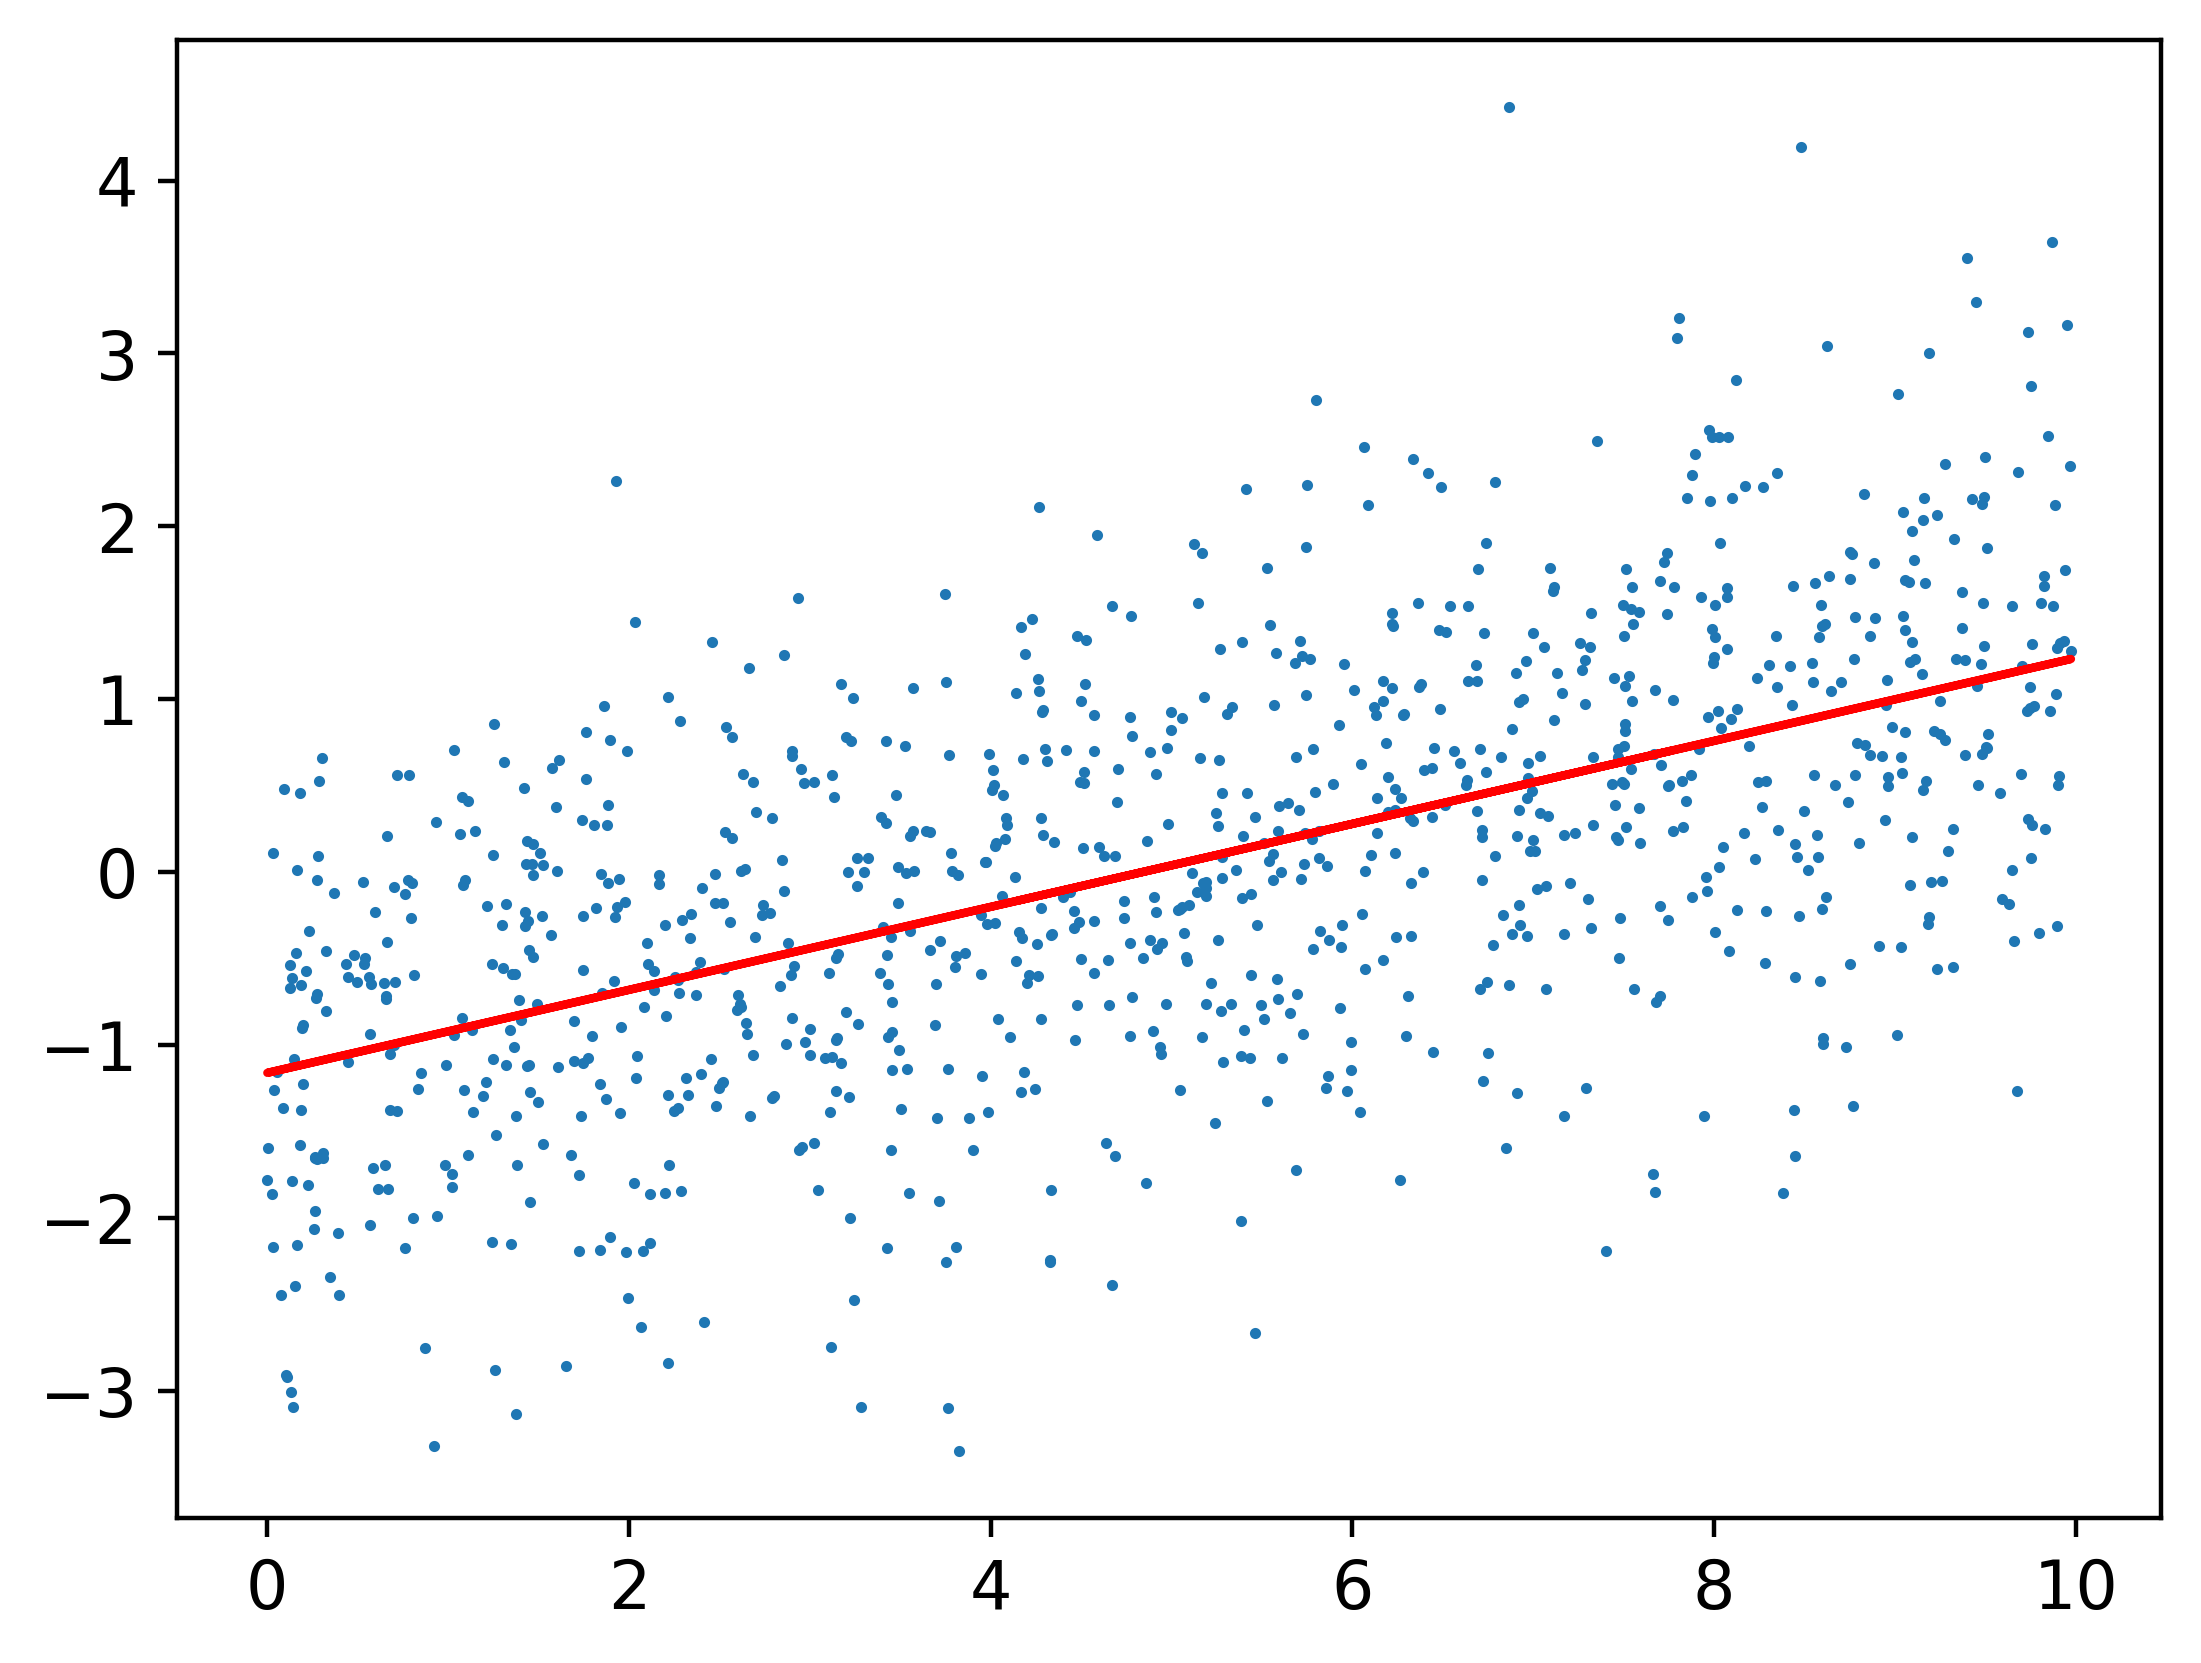

In [61]:
plt.scatter(X, y, s=1)
plt.plot(X, y_pred, 'r')

Enquanto no caso atual estamos vendo como o modelo "ajusta" os mesmos dados com os quais foi treinado, enteriormente examinamos previsoes do modelo para dados novos e desconhecidos, em ML geralmente o que nos interessa sao os recursos preditivos. No entanto, no fim das contas as previsoes tanto dos dados de treinamento usados para ajustar o modelo, quanto dos dados de teste, que nao foram usados no ajuste, sao importantes para entendermos o funcionamento do modelo.

Metricas de desempenho de modelos para a classificacao binaria

In [62]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df['EDUCATION'].values.reshape(-1, 1), df['default payment next month'].values, test_size=0.2, random_state=24)
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((21331, 1), (5333, 1), (21331,), (5333,))

In [63]:
#verificar se a fração de positivos e negativos é aproximadamente a mesma em ambos os conjuntos
np.mean(y_train), np.mean(y_test)

(np.float64(0.223102526838873), np.float64(0.21657603600225014))

acurarica da classificacao

In [64]:
from sklearn.linear_model import LogisticRegression

example_lr = LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True, intercept_scaling=1, max_iter=100,
                           n_jobs=None, penalty='l2', random_state=None, solver='liblinear', tol=0.0001,
                           verbose=0, warm_start=False)
example_lr.fit(X_train, y_train)
y_pred = example_lr.predict(X_test)
y_pred[0:10]   

/home/aimee/Área de trabalho/Data-Science-Project-Python-LEARNING/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [65]:
#Acurarica da classificacao
is_correct = y_pred == y_test
np.mean(is_correct)

np.float64(0.7834239639977498)

In [66]:
#outras formas de calcular a acuracia
example_lr.score(X_test, y_test)

0.7834239639977498

In [67]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.7834239639977498

In [68]:
P = sum(y_test)
P

np.int64(1155)

In [69]:
TP = sum((y_test == 1) & (y_pred == 1))
TP

np.int64(0)

In [70]:
TPR = TP / P
TPR

np.float64(0.0)

In [71]:
FN = sum((y_test == 1) & (y_pred == 0))
FN

np.int64(1155)

In [72]:
FNR = FN / P
FNR

np.float64(1.0)

In [73]:
N = sum(y_test == 0)
N

np.int64(4178)

In [74]:
TN = sum((y_test == 0) & (y_pred == 0))
TN

np.int64(4178)

In [75]:
FP = sum((y_test == 0) & (y_pred == 1))
FP

np.int64(0)

In [76]:
TNR = TN / N
FPR = FP / N
print('the true negative rate is {} and the false positive rate is {}'.format(TNR, FPR))

the true negative rate is 1.0 and the false positive rate is 0.0


In [77]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[4178,    0],
       [1155,    0]])

In [78]:
#Obtendo probabilidade previstas a partir de um modelo de regressao logistica
y_pred_proba = example_lr.predict_proba(X_test)
y_pred_proba

array([[0.77516994, 0.22483006],
       [0.77516994, 0.22483006],
       [0.78742055, 0.21257945],
       ...,
       [0.78742055, 0.21257945],
       [0.78742055, 0.21257945],
       [0.78742055, 0.21257945]], shape=(5333, 2))

In [79]:
prob_sum = np.sum(y_pred_proba, axis=1)
prob_sum

array([1., 1., 1., ..., 1., 1., 1.], shape=(5333,))

In [80]:
np.unique(prob_sum)

array([1.])

In [81]:
pos_proba = y_pred_proba[:, 1]
pos_proba

array([0.22483006, 0.22483006, 0.21257945, ..., 0.21257945, 0.21257945,
       0.21257945], shape=(5333,))

(array([2.000e+00, 1.883e+03, 0.000e+00, 2.519e+03, 8.490e+02, 0.000e+00,
        2.300e+01, 0.000e+00, 4.500e+01, 1.200e+01]),
 array([0.20082342, 0.20861145, 0.21639948, 0.22418752, 0.23197555,
        0.23976358, 0.24755161, 0.25533965, 0.26312768, 0.27091571,
        0.27870374]),
 <BarContainer object of 10 artists>)

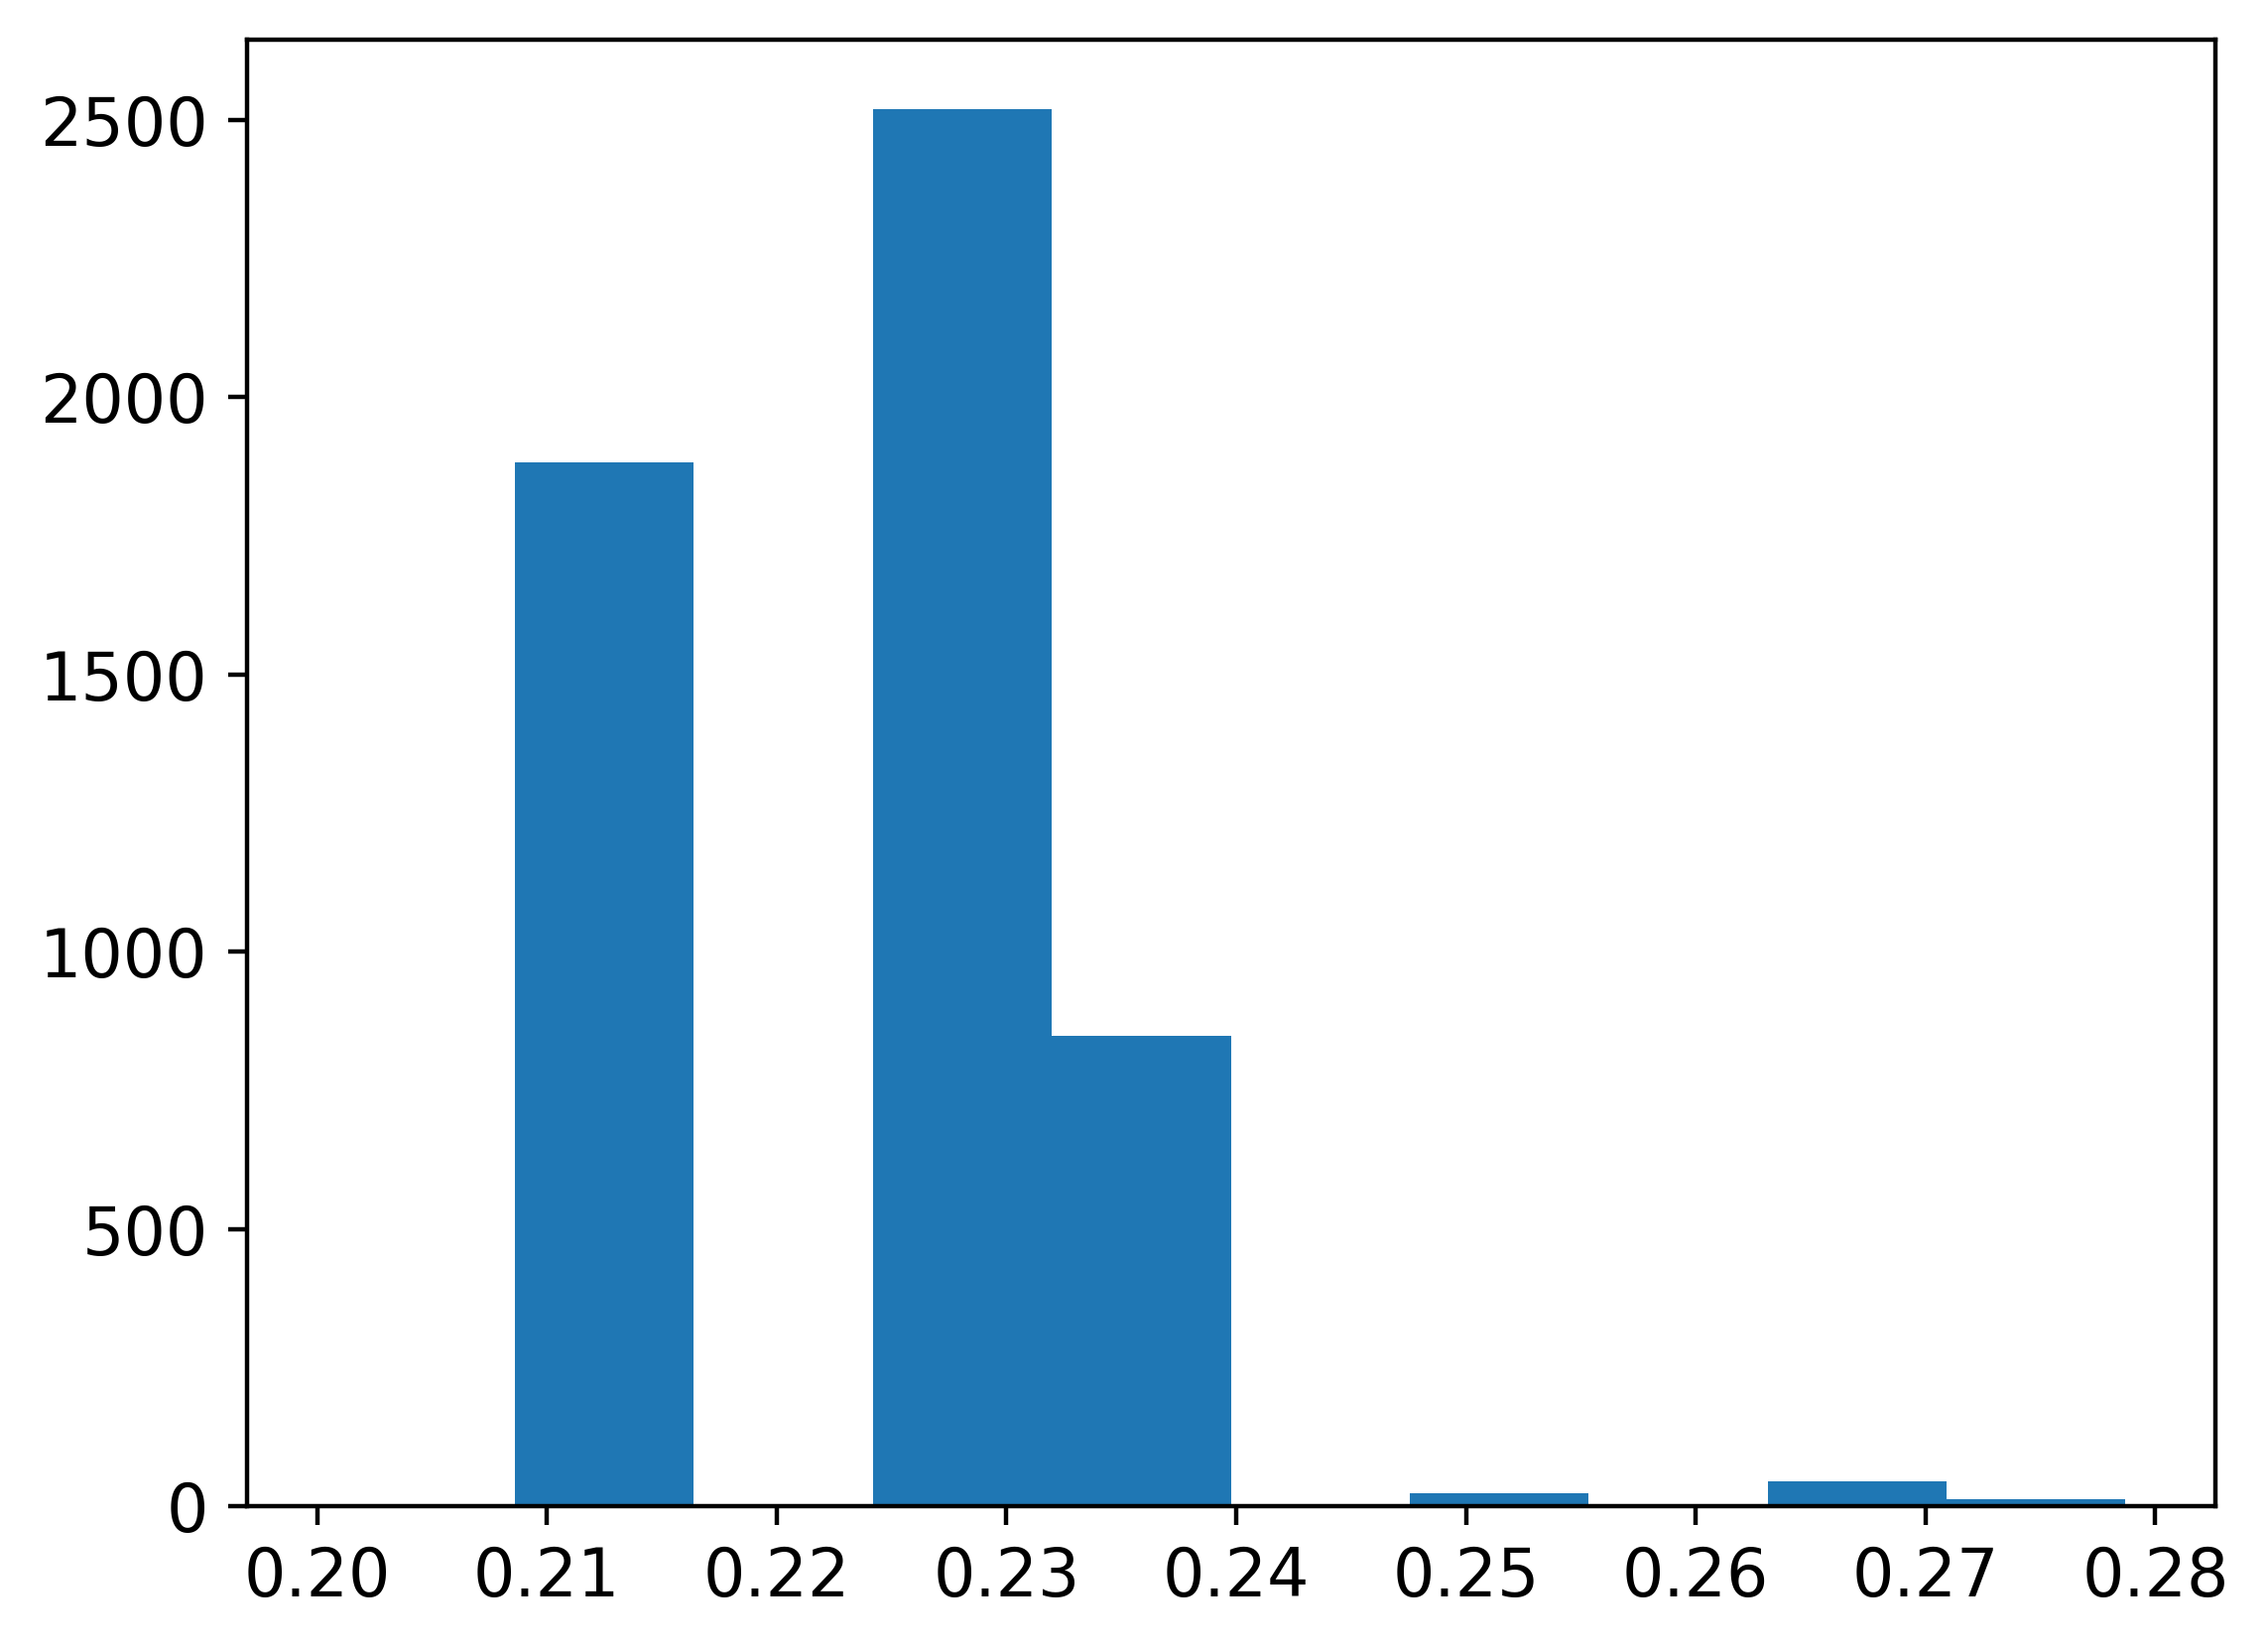

In [82]:
plt.hist(pos_proba)

Text(0, 0.5, 'Number of clients')

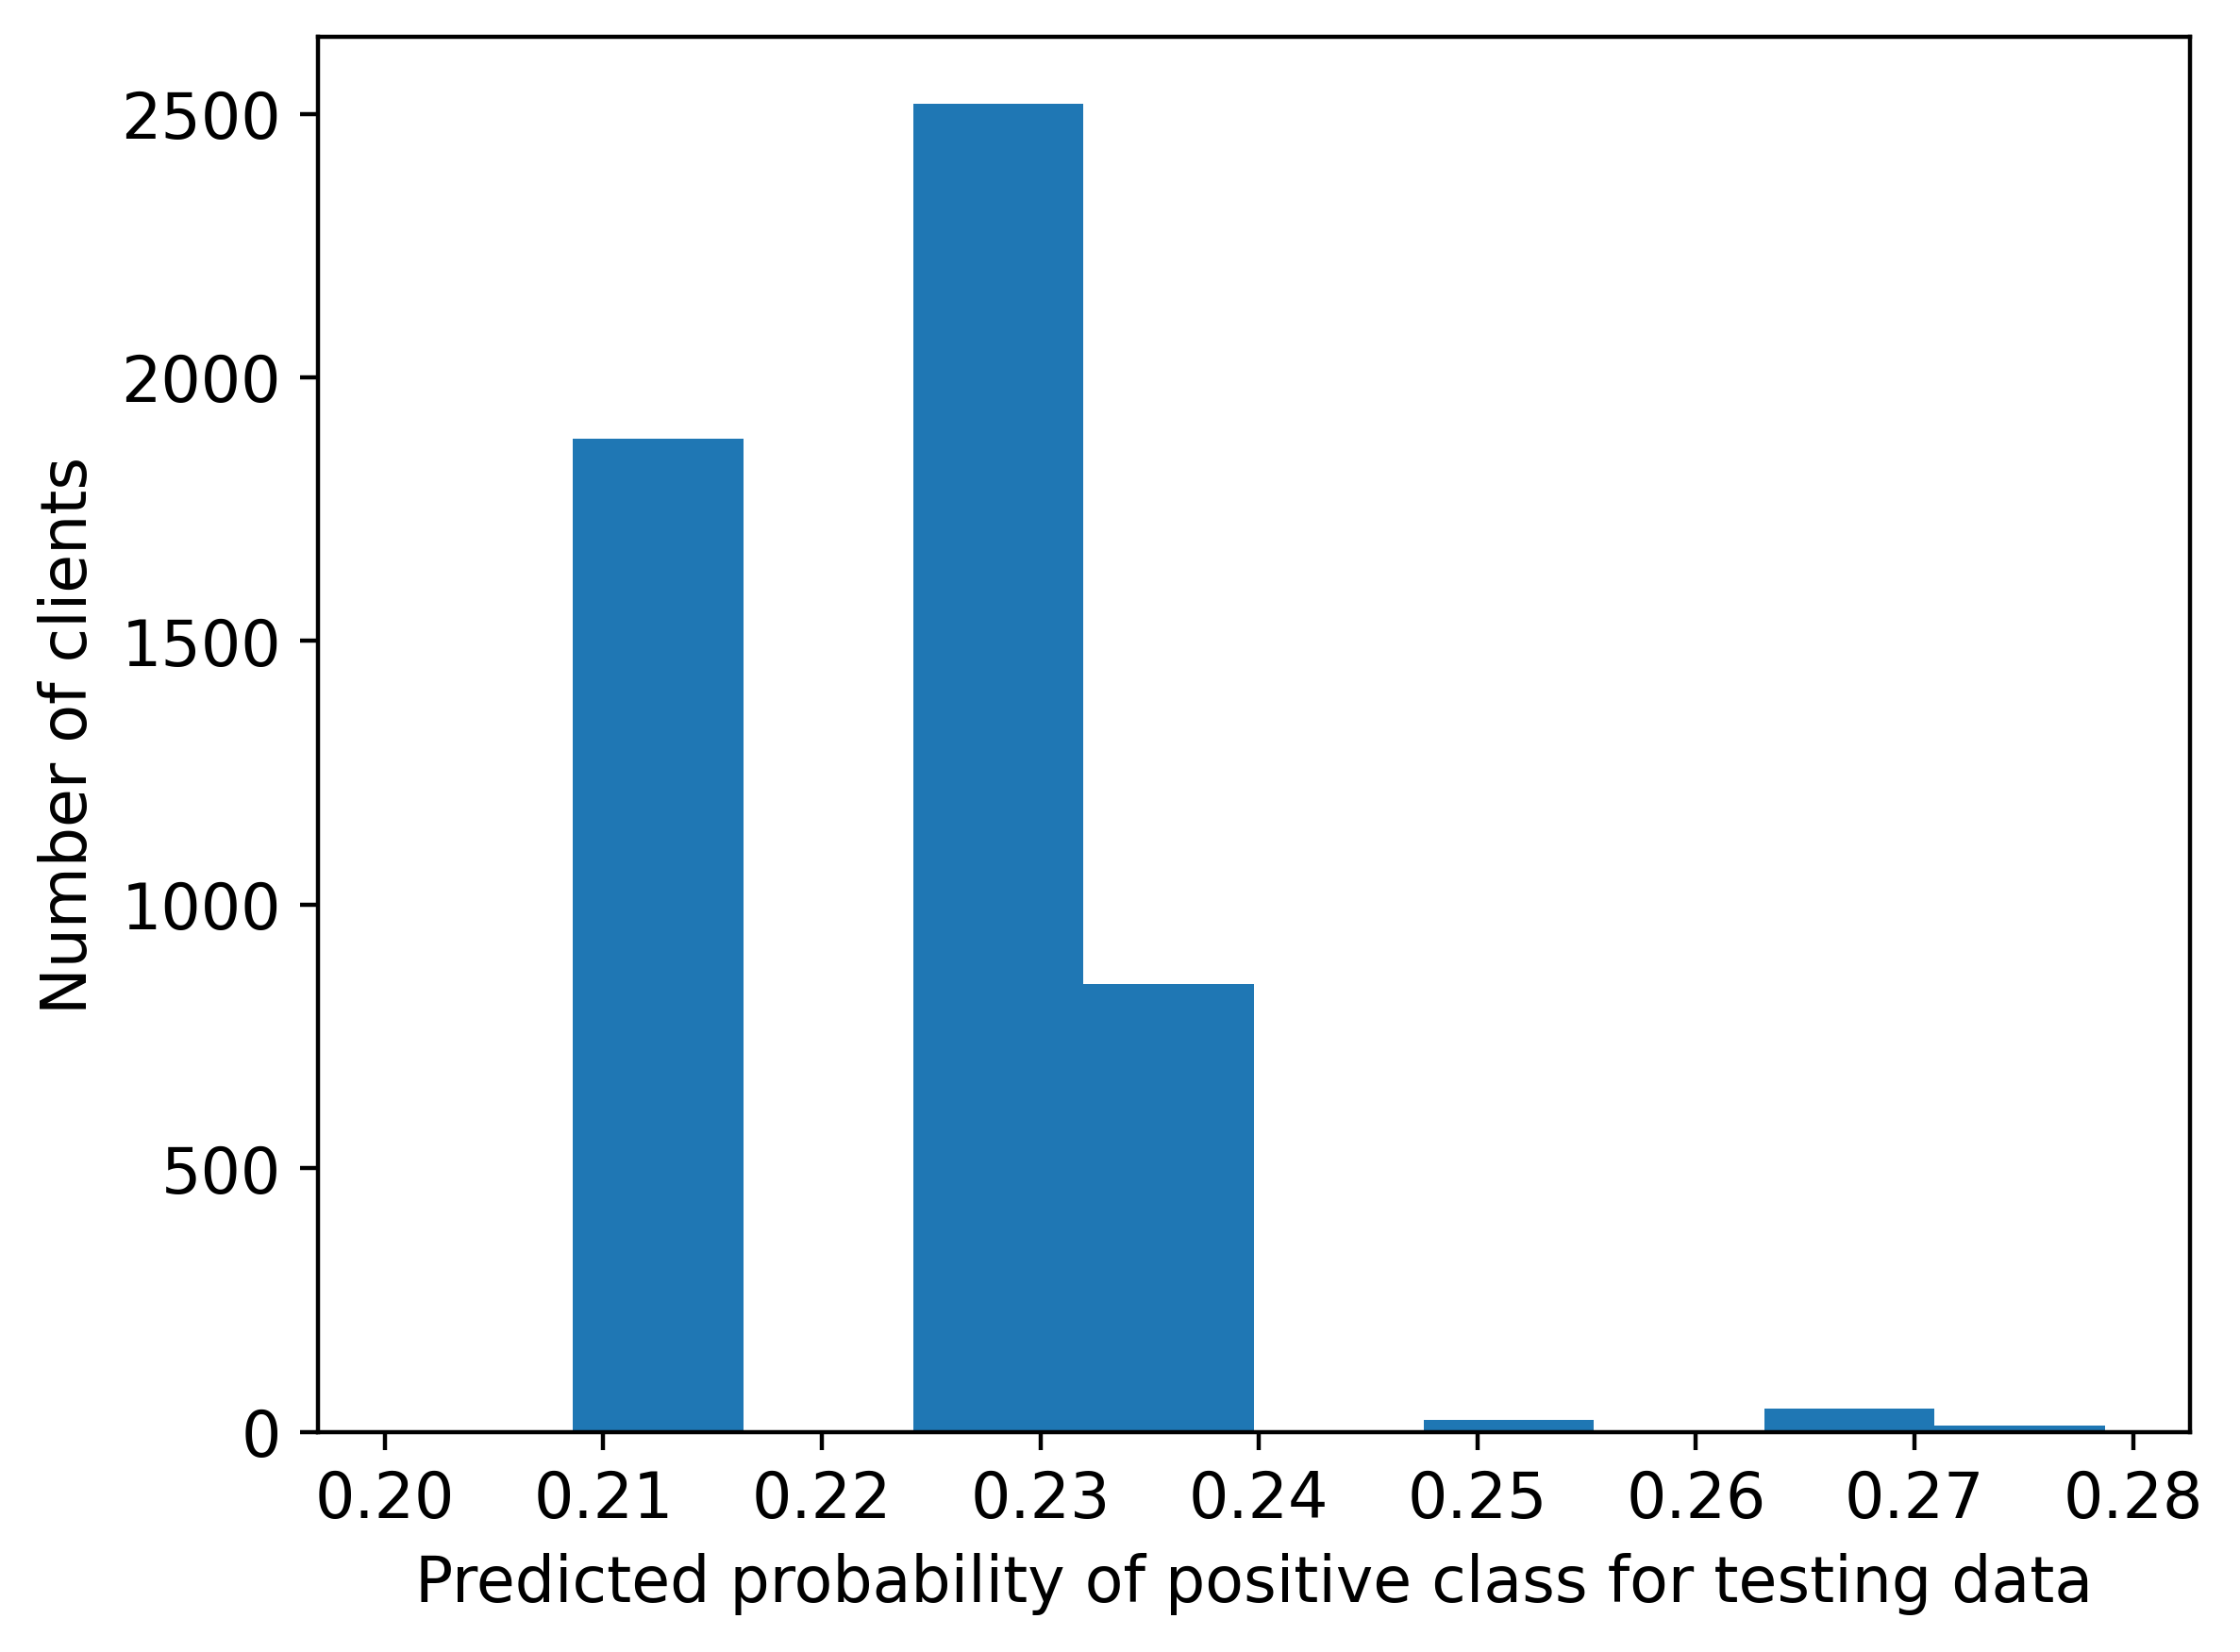

In [83]:
mpl.rcParams['font.size'] = 12
plt.hist(pos_proba)
plt.xlabel('Predicted probability of positive class for testing data')
plt.ylabel('Number of clients')

In [84]:
#Dividindo as probabilidades previstas em duas amostras, uma contendo apenas amostras positivas e outra apenas amostras negativas
pos_sample_pos_proba = pos_proba[y_test == 1]
neg_sample_pos_proba = pos_proba[y_test == 0]

Text(0, 0.5, 'Number of clients')

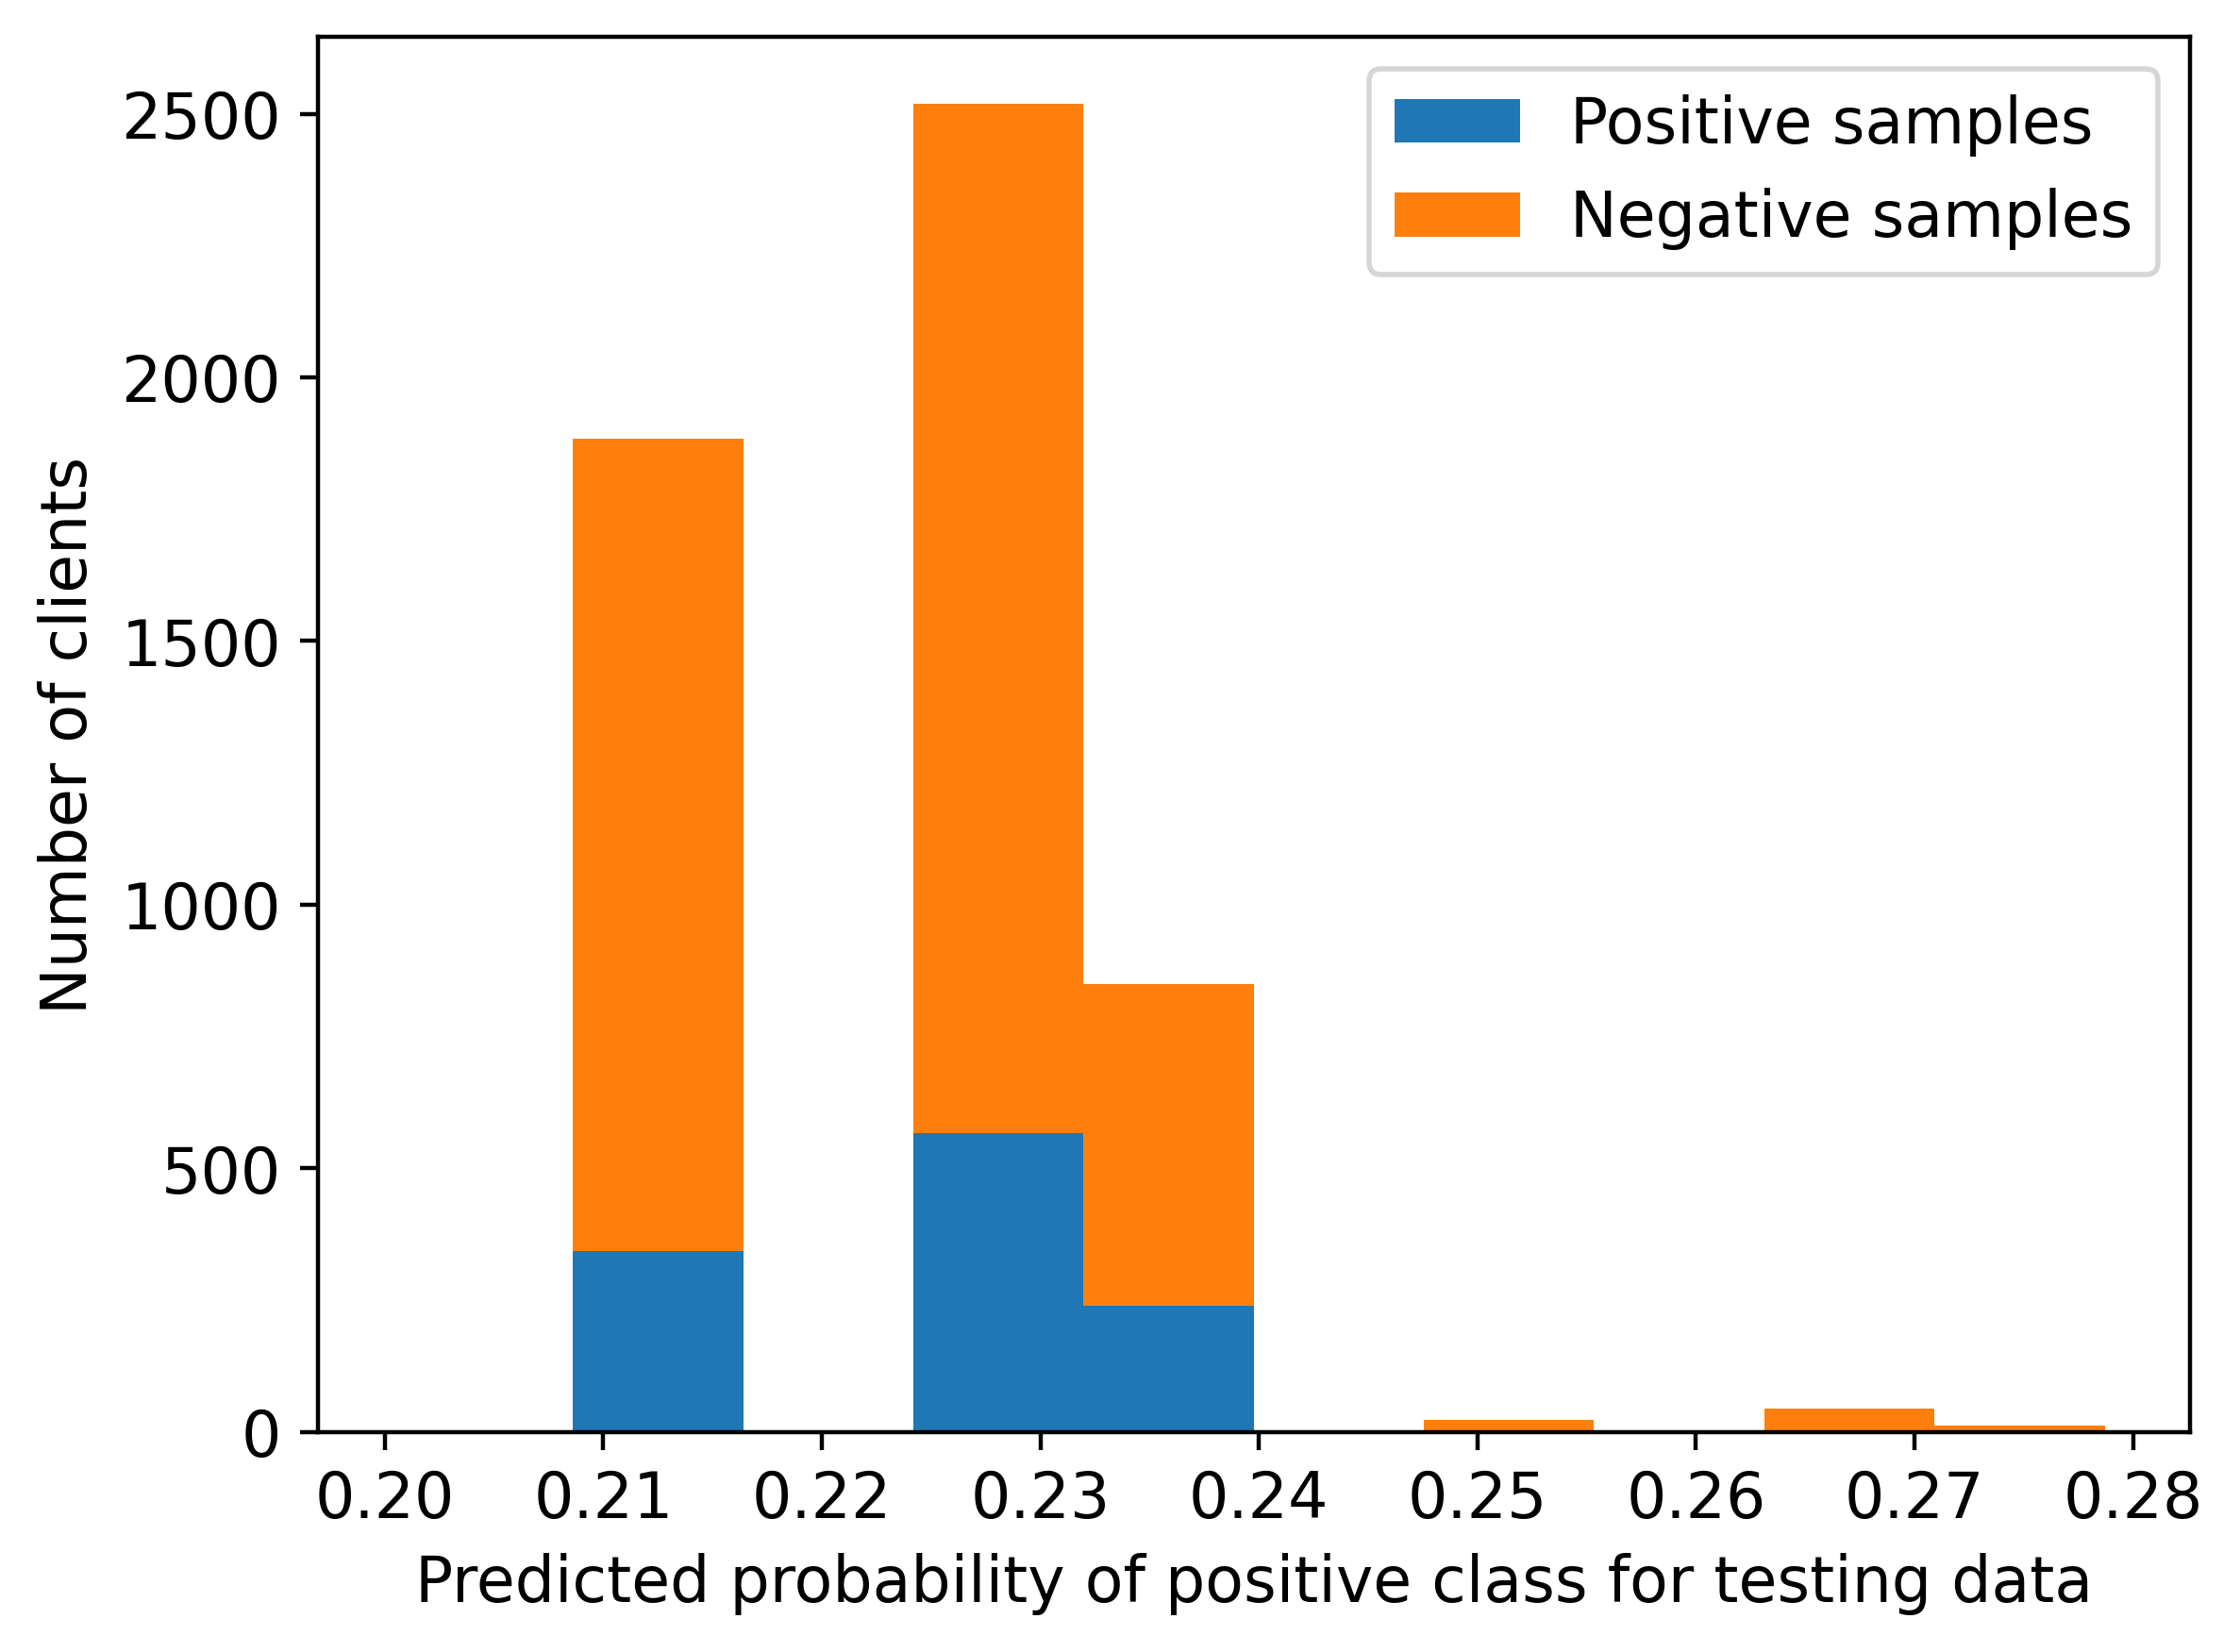

In [85]:
plt.hist([pos_sample_pos_proba, neg_sample_pos_proba], histtype='barstacked')
plt.legend(['Positive samples', 'Negative samples'])
plt.xlabel('Predicted probability of positive class for testing data')
plt.ylabel('Number of clients')

In [86]:
#gerar arrays de TPRs e FPRs da curva de ROC
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, pos_proba)

Text(0.5, 1.0, 'ROC curve for logistic regression model')

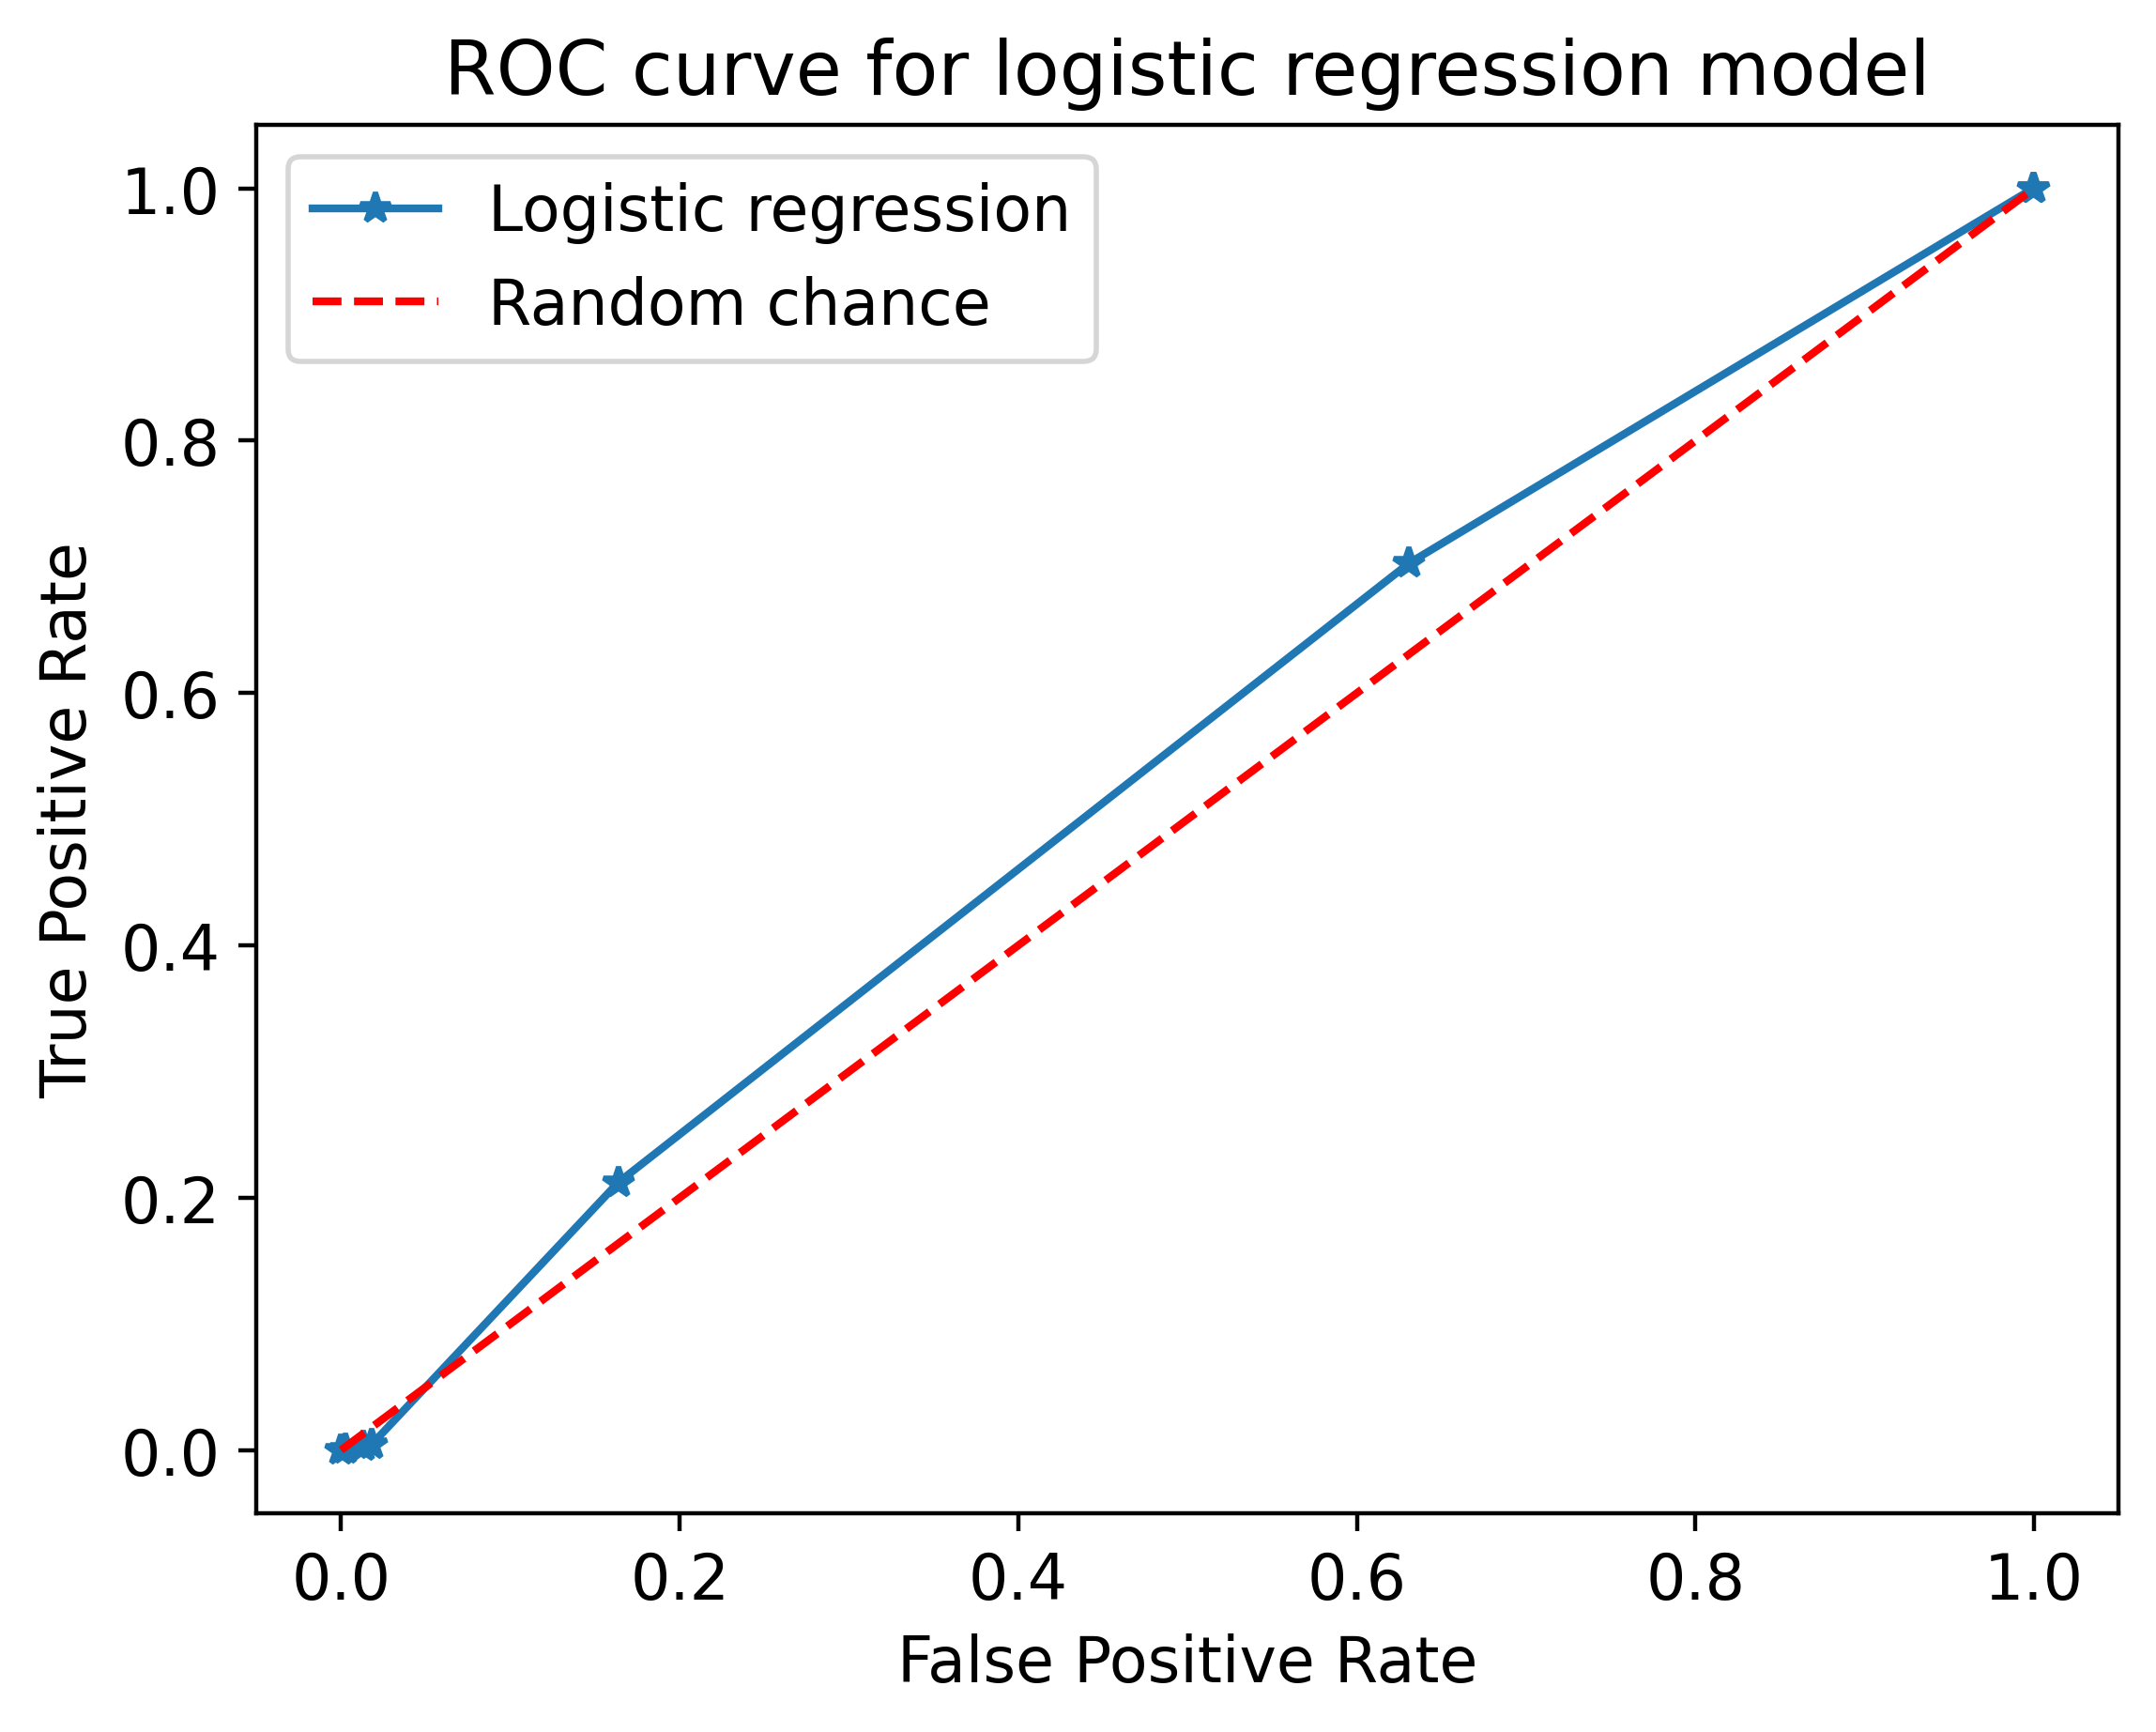

In [87]:
plt.plot(fpr, tpr, '*-')
plt.plot([0, 1], [0, 1], 'r--')
plt.legend(['Logistic regression', 'Random chance'])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve for logistic regression model')

In [88]:
thresholds

array([       inf, 0.27870374, 0.26451935, 0.25080585, 0.23757365,
       0.22483006, 0.21257945, 0.20082342])

In [89]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, pos_proba)

0.5439402228535785

In [90]:
from sklearn.metrics import precision_recall_curve
precision_recall_curve(y_test, pos_proba)

(array([0.21657604, 0.21665729, 0.23549884, 0.26372443, 0.0625    ,
        0.05263158, 0.08333333, 1.        ]),
 array([1.00000000e+00, 1.00000000e+00, 7.03030303e-01, 2.12121212e-01,
        4.32900433e-03, 2.59740260e-03, 8.65800866e-04, 0.00000000e+00]),
 array([0.20082342, 0.21257945, 0.22483006, 0.23757365, 0.25080585,
        0.26451935, 0.27870374]))